In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt


### Functions for plotting the function and the gradient descent trajectories

In [2]:
'''
    The following function show the function on a 3D surface plot
'''
def plot_3Dsurface(X,Y,Z,title= "surface plot"):
    # Create figure
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    # Surface plot
    surf = ax.plot_surface(
        X, Y, Z,
        cmap='viridis',
        linewidth=0,
        antialiased=True
    )

    # Labels
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.set_zlabel('$f(x,y)$', fontsize=12)
    ax.set_title(title, fontsize=15)

    # Color bar
    cbar = fig.colorbar(surf, shrink=0.6, aspect=12)
    cbar.set_label('Function value')

    # Better viewing angle
    ax.view_init(elev=35, azim=-60)

    plt.tight_layout()
    plt.show()

'''
    The following function show the function on a 2D contour plot
'''
def plot_2Dcontour(X,Y,Z,title= "contour plot"):
    
    plt.figure(figsize=(6, 4))

    # levels = np.logspace(0, 5, 35)

    contour = plt.contourf(
        X, Y, Z,
        # levels=levels,
        cmap='viridis'
    )

    plt.colorbar(label='Function value')
    plt.contour(
        X, Y, Z,
        # levels=levels,
        colors='k',
        linewidths=0.25,
        alpha=0.4
    )

    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_trajectory_surface(X, Y, Z, trajectory, title="Trajectory of algorithm"):
    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X, Y, Z,
        cmap='viridis',
        alpha=0.85,
        linewidth=0
    )

    # Gradient Descent trajectory
    Ztraj = f(trajectory[:,0], trajectory[:,1])

    ax.plot(
        trajectory[:,0],
        trajectory[:,1],
        Ztraj,
        '-o',
        color='red',
        linewidth=3,
        markersize=5,
        label='Gradient Descent'
    )

    # Starting point
    ax.scatter(
        trajectory[0,0],
        trajectory[0,1],
        Ztraj[0],
        color='blue',
        s=70,
        label='Start'
    )

    # Final point
    ax.scatter(
        trajectory[-1,0],
        trajectory[-1,1],
        Ztraj[-1],
        color='black',
        s=70,
        label='End'
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")
    ax.set_title(title)

    fig.colorbar(surf, shrink=0.6)

    ax.view_init(elev=35, azim=-60)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_trajectory_contour(X, Y, Z, path, title="Trajectory of algorithm"):
    plt.figure(figsize=(7,5))

    levels = np.logspace(0,5,30)

    plt.contourf(X,Y,Z,
                levels=levels,
                cmap='viridis')

    plt.contour(X,Y,Z,
                levels=levels,
                colors='red',
                linewidths=0.4,
                alpha=0.4)

    # Draw arrows showing each step
    for i in range(len(path)-1):
        plt.annotate(
            "",
            xy=path[i+1],
            xytext=path[i],
            arrowprops=dict(
                arrowstyle="->",
                color="red",
                lw=2
            )
        )

    plt.plot(path[:,0], path[:,1], 'ro', markersize=4)
    plt.plot(path[0,0], path[0,1], 'bs', markersize=9, label='Start')
    plt.plot(path[-1,0], path[-1,1], 'k*', markersize=14, label='End')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    plt.show()

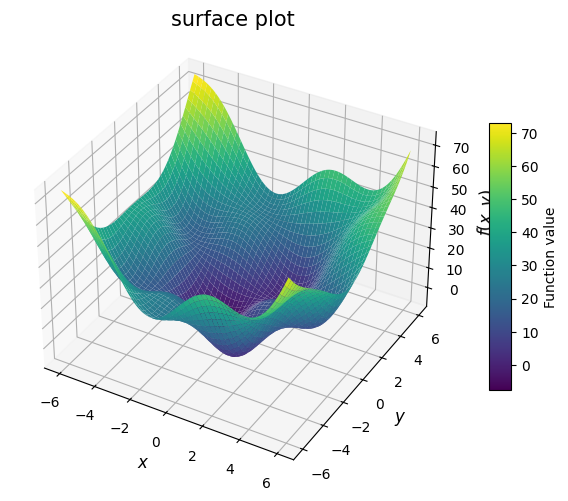

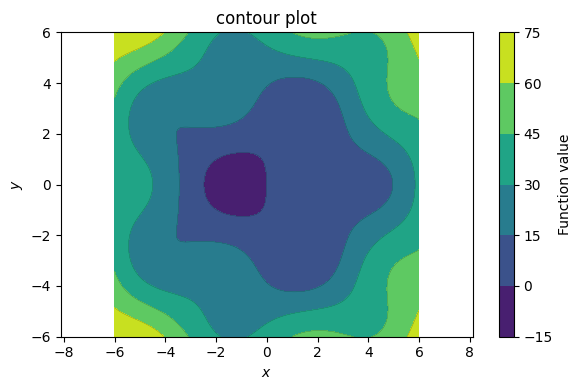

In [3]:
## function definition

def f(x, y):
    return x**2 + y**2 + 10 * np.sin(x) * np.cos(y)

def grad_f(x, y):
    df_dx = 2*x + 10*np.cos(x)*np.cos(y)
    df_dy = 2*y - 10*np.sin(x)*np.sin(y)
    return np.array([df_dx, df_dy])
    
# Create grid
x = np.linspace(-6, 6, 300)
y = np.linspace(-6, 6, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)


plot_3Dsurface(X,Y,Z)
plot_2Dcontour(X,Y,Z)

### Gradient descent example


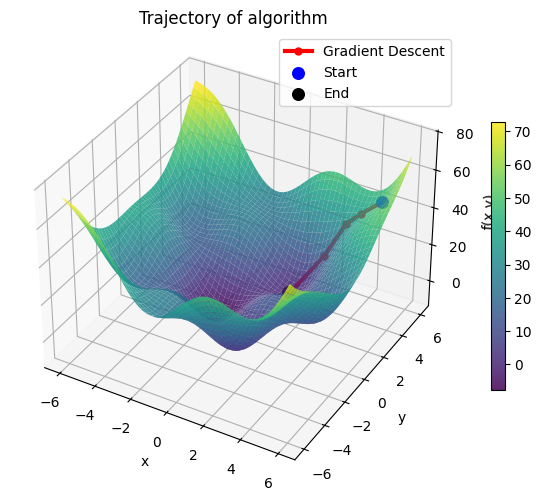

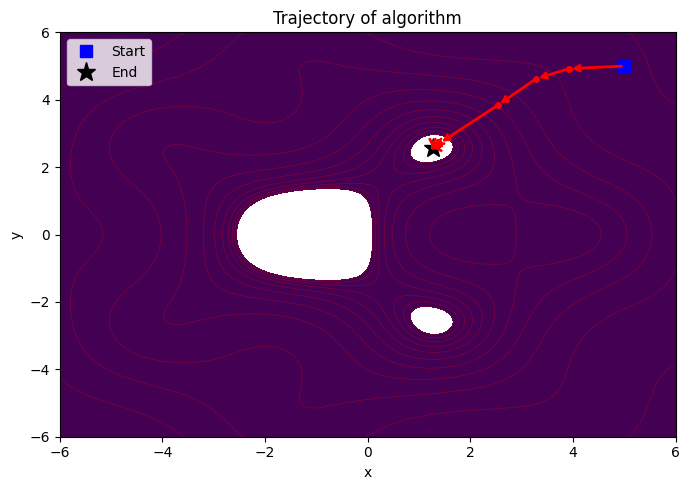

In [4]:

alpha = 0.1
w0 = np.array([5.0, 5.0])
w = w0.copy()
iterations = 100
trajectory = [w.copy()]
for _ in range(iterations):
    grad = grad_f(w[0], w[1])
    w = w - alpha * grad
    trajectory.append(w.copy())
    # print(w)

trajectory = np.array(trajectory)

xgrid = np.linspace(-6,6,400)
ygrid = np.linspace(-6,6,400)
X,Y = np.meshgrid(xgrid,ygrid)
Z = f(X,Y)

plot_trajectory_surface(X, Y, Z, trajectory, title="Trajectory of algorithm")

plot_trajectory_contour(X, Y, Z, trajectory, title="Trajectory of algorithm")

## Algorithms

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(w):
    return ____________

def gradient_f(w):
    return _____________


## Momentum based gradient descent
def momentum_method(w0, learning_rate, momentum_rate, iterations):
    w = w0.copy()
    v = np.zeros_like(w)
    trajectory = [w.copy()]

    for _ in range(iterations):
        grad = gradient_f(w)
        v = momentum_rate*v - learning_rate*grad
        w += v
        trajectory.append(w.copy())

    return np.array(trajectory)

## Nesterov's accelerated gradient descent
def acceleration_method(w0, learning_rate, momentum_rate, iterations):
    w = w0.copy()
    v = np.zeros_like(w)
    trajectory = [w.copy()]

    for _ in range(iterations):
        y = w + momentum_rate*v
        grad = gradient_f(y)
        v = __________________
        w += ________________
        trajectory.append(w.copy())

    return np.array(trajectory)

## Stochastic Gradient Descent (SGD)
def sgd_method(w0, learning_rate, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    iterations = 100
    for _ in range(iterations):
        grad = 


        w += _______________
        trajectory.append(w.copy())

    return np.array(trajectory)

## Adaptive Gradient (AdaGrad)
def AdaGrad_method(w0, learning_rate, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    g = np.zeros_like(w)
    # grad_square = np.zeros_like(w)

    for _ in range(iterations):
        grad = _______________
        grad_square += ________________
        adjusted_lr = ___________________
        w += __________________
        trajectory.append(w.copy())

    return np.array(trajectory)
    
## RMSprop algorithm
def RMSprop_method(w0, learning_rate, beta, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    grad_square = np.zeros_like(w)
    weighted_avg_grad = np.zeros_like(w)

    for _ in range(iterations):
        grad = _______________
        grad_square = ___________________
        weighted_avg_grad = ____________________
        adjusted_lr = ___________________
        w += __________________
        trajectory.append(w.copy())

    return np.array(trajectory)

## Adam optimization algorithm
def Adam_method(w0, learning_rate, beta1, beta2, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    m = np.zeros_like(w)
    v = np.zeros_like(w)
# w0, learning_rate, beta1, beta2, epsilon, iterations
    for t in range(1, iterations + 1):
        grad = _______________
        m = ______________________
        v = ______________________
        m_hat = ______________________
        v_hat = ______________________
        adjusted_lr = ______________________
        w += ______________________
        trajectory.append(w.copy())

    return np.array(trajectory)
